# Models 4 and 5 - Service batch size range (detailed diagrams)

## Load libraries

In [47]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import libs.tools as tools

plt.style.use('seaborn-v0_8')

## Load and process data

In [48]:
# Number of operators needed in bS=1 case
c_needed = 16

# bI=1
data_bI1 = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "range" and rec["bI"] == 1)
tools.load_statistics(data_bI1)

# bI=1..4
data_bI1234 = tools.prepare_statistics(c_needed, lambda rec: rec["mode"] == "range" and isinstance(rec["bI"], str))
tools.load_statistics(data_bI1234)

### Calculate E[W] increasement relative to $b_S$=16..16 case

In [49]:
for rec in data_bI1:
    base = tools.find_same_with_other_b(data_bI1, rec, 1, c_needed, c_needed, None)
    rec["E[W]rel"] = rec["E[W]"] / base["E[W]"]

### Calculate E[W] increasement relative to $b_S$=16..16 and $b_I=(1,1,1,1)$ case

In [50]:
for rec in data_bI1234:
    base = tools.find_same_with_other_b(data_bI1234, rec, "1111", c_needed, c_needed, None)
    rec["E[W]rel"] = rec["E[W]"] / base["E[W]"]

## Plot results

In [51]:
bI_rates_levels = [
    [1, 1, 1, 1],
    [1, 2, 3, 4],
    [4, 3, 2, 1],
    [1, 2, 2, 1],
    [2, 1, 1, 2]
]

colors = ["blue", "red", "green", "orange", "purple"]

### E[W] (relative) for $b_I=1$ (Model 3)

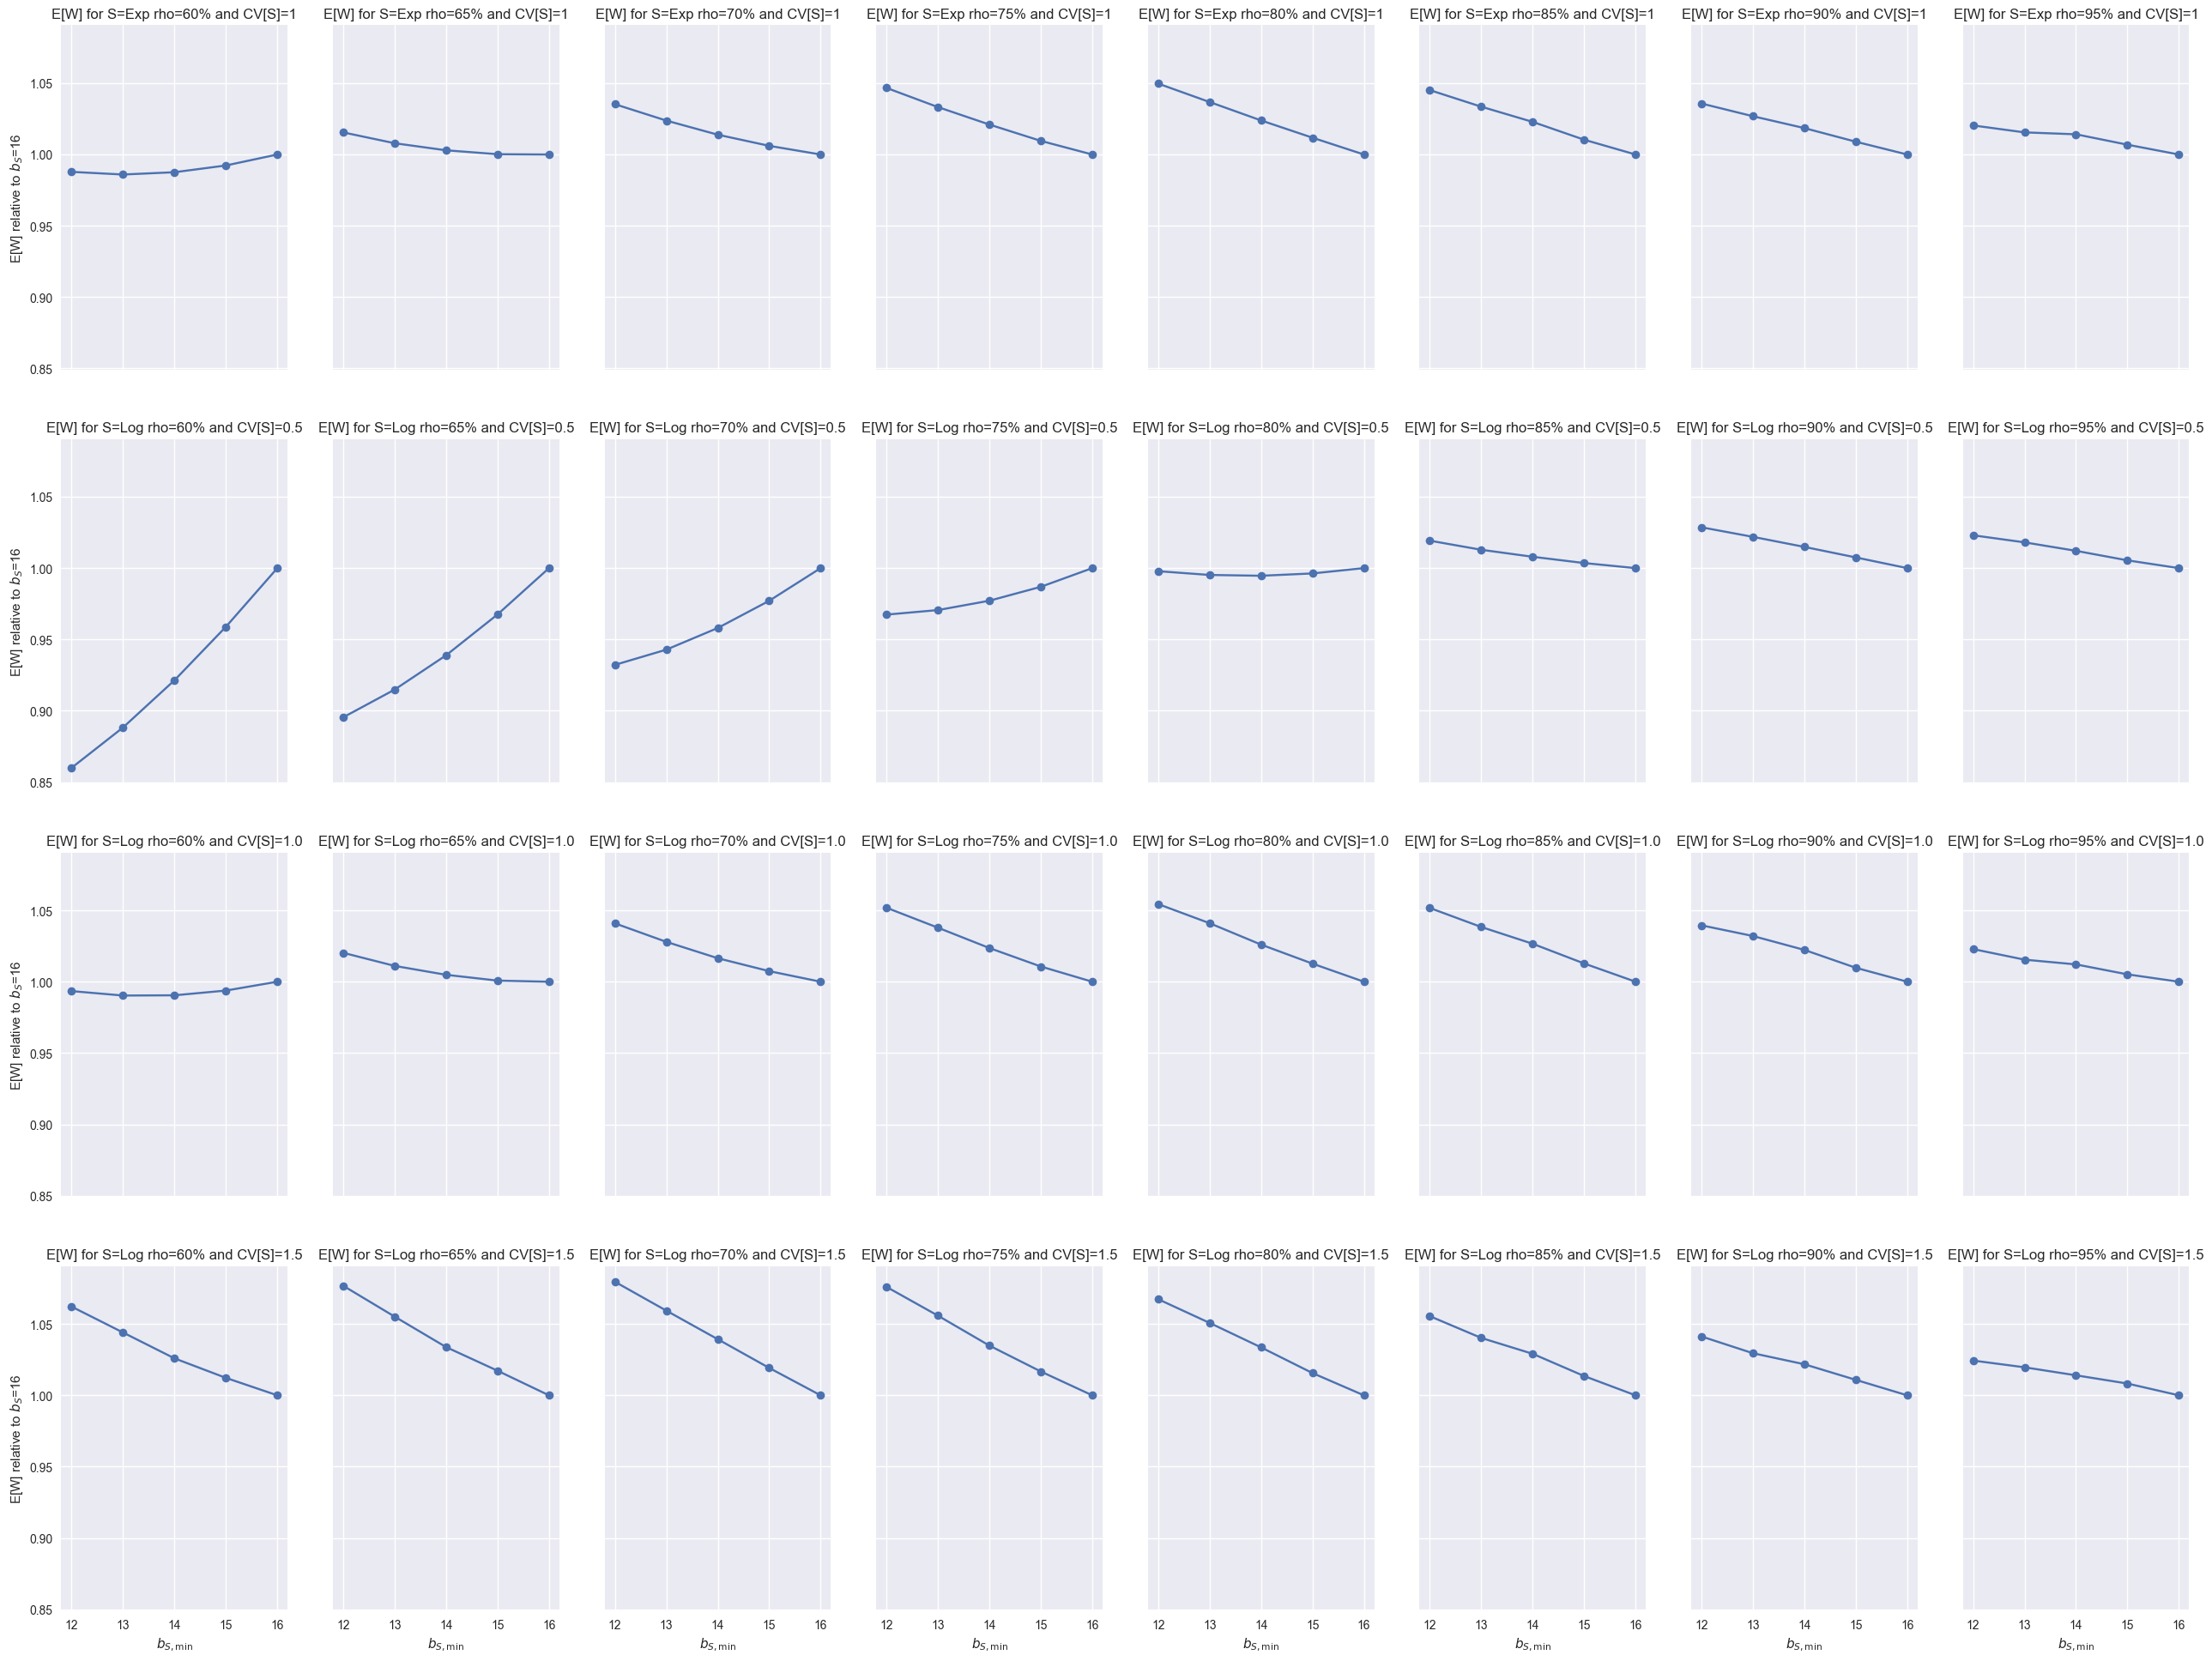

In [52]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.60 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data_bI1 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            b = rec["b_min"]
            name = rec["name_short"]
            plot_sim_data.append({"b": b, "name": name, "E[W]": rec["E[W]rel"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

        x = [rec["b"] for rec in plot_sim_data]
        y_sim = [rec["E[W]"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o')
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("E[W] relative to $b_S$=16")

        if i == 3:
            ax1.set_xlabel("$b_{S,\\min}$")

        ax1.set_title(f"E[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model04-EWrel-details.png", format="png", bbox_inches='tight', pad_inches=0)

### E[W] (absolute) for $b_I=1$ (Model 3)

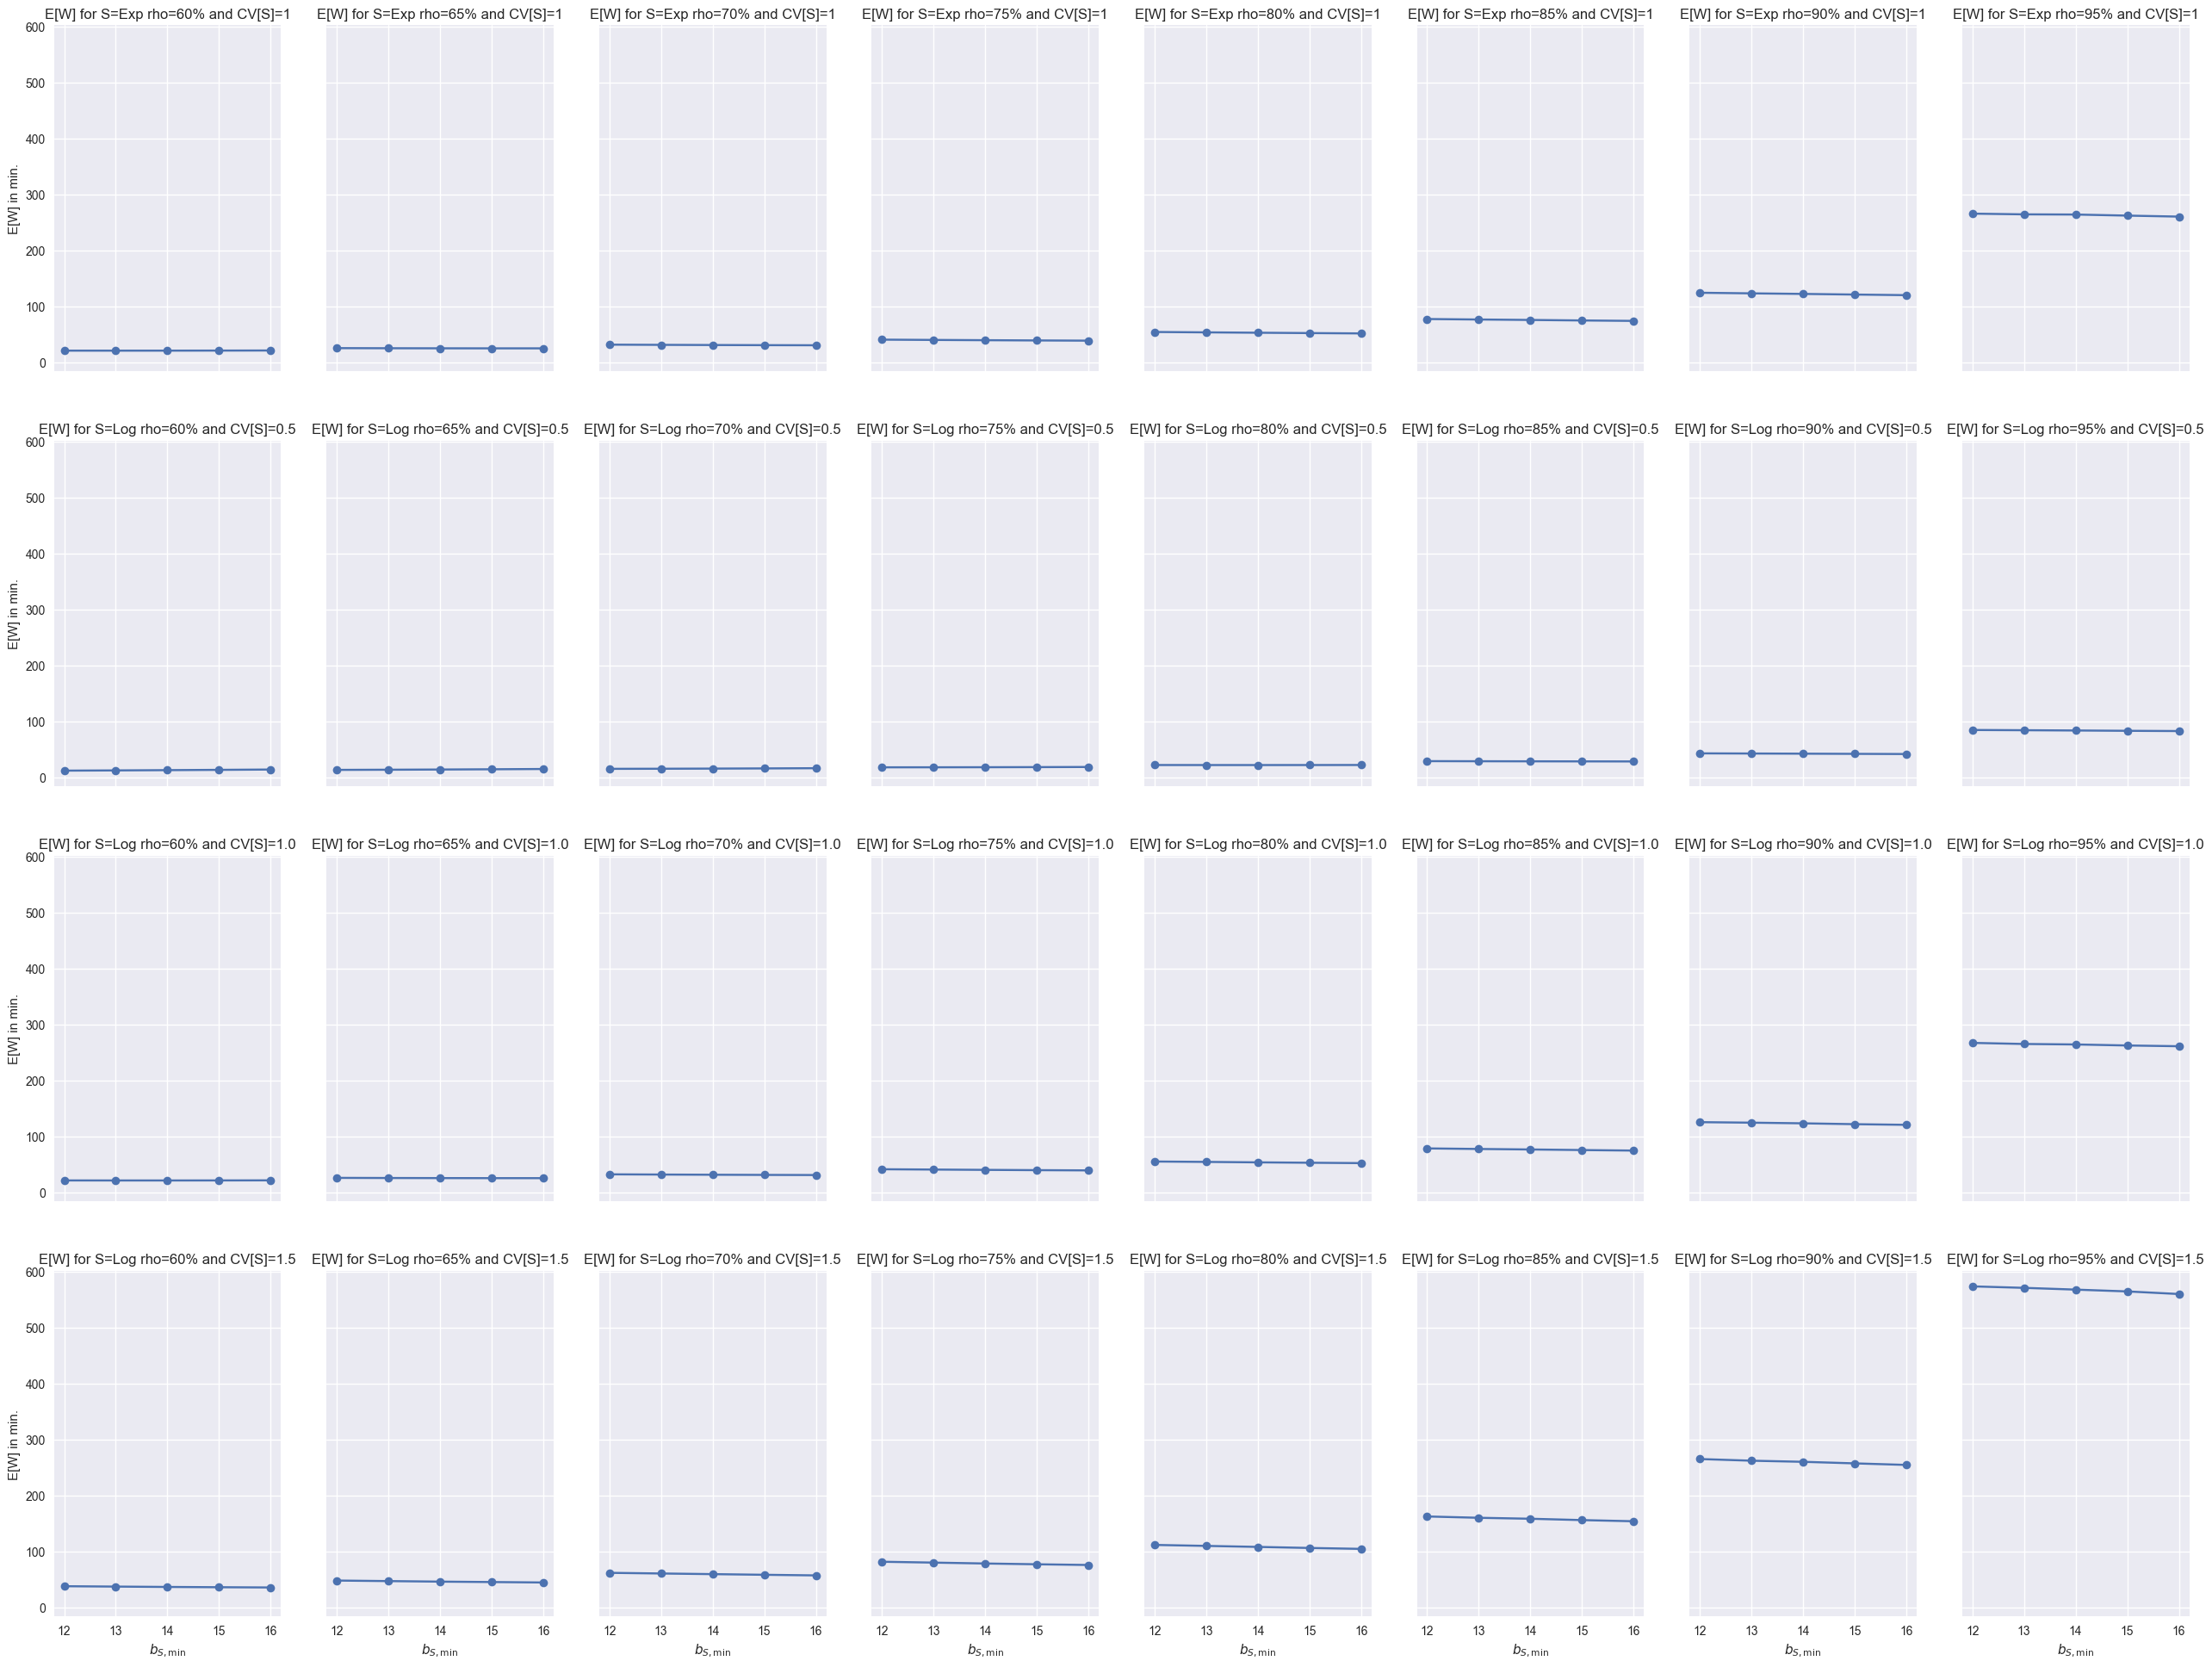

In [53]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.60 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data_bI1 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            b = rec["b_min"]
            name = rec["name_short"]
            plot_sim_data.append({"b": b, "name": name, "E[W]": rec["E[W]"] / 60})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

        x = [rec["b"] for rec in plot_sim_data]
        y_sim = [rec["E[W]"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o')
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("E[W] in min.")
        # ax1.set_ylim(0, 50)

        if i == 3:
            ax1.set_xlabel("$b_{S,\\min}$")

        ax1.set_title(f"E[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model04-EW-details.png", format="png", bbox_inches='tight', pad_inches=0)

### CV[W] for $b_I=1$ (Model 3)

Maximum relative delta (W): 9.61%
Maximum relative delta (V): 6.67%


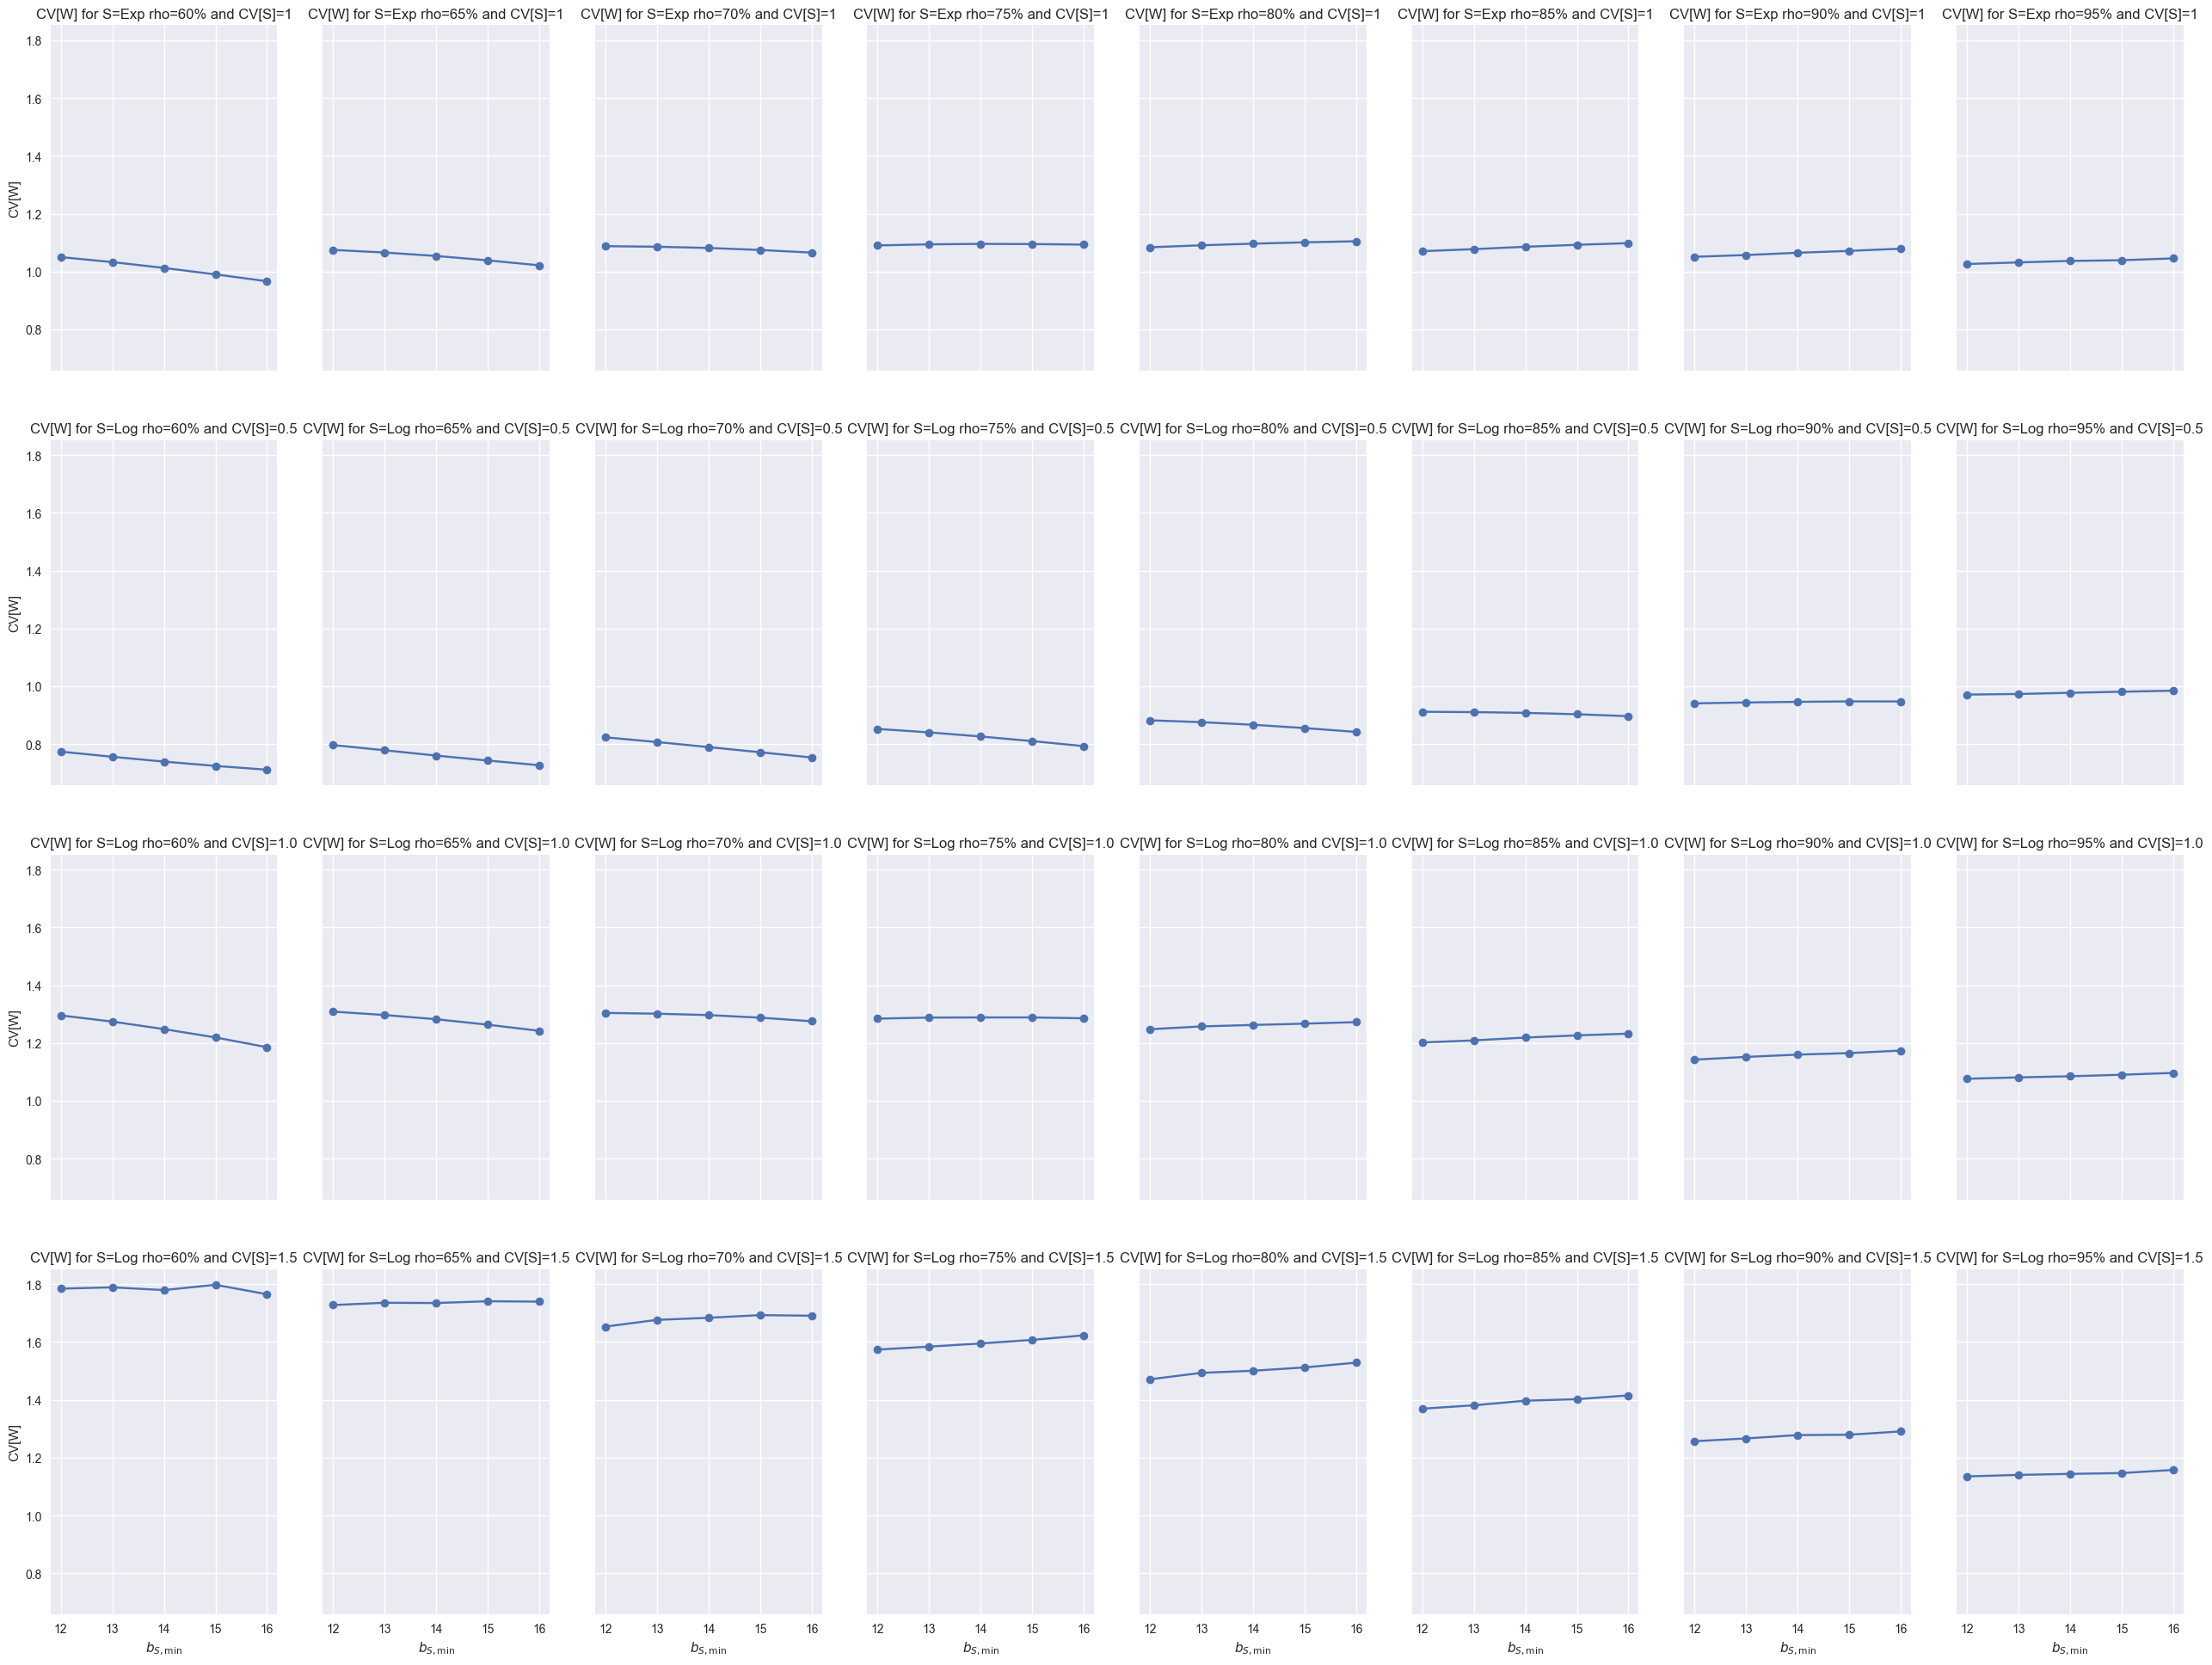

In [54]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

max_rel_delta_W = 0
max_rel_delta_V = 0

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.60 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data_bI1 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            b = rec["b_min"]
            name = rec["name_short"]
            plot_sim_data.append({"b": b, "name": name, "CV[W]": rec["CV[W]"], "CV[V]": rec["CV[V]"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

        x = [rec["b"] for rec in plot_sim_data]
        y_sim = [rec["CV[W]"] for rec in plot_sim_data]
        y_sim_CVV = [rec["CV[V]"] for rec in plot_sim_data]

        rel_delta_W = abs((y_sim[4] - y_sim[0]) / y_sim[4])
        max_rel_delta_W = max(max_rel_delta_W, rel_delta_W)

        rel_delta_V = abs((y_sim_CVV[4] - y_sim_CVV[0]) / y_sim_CVV[4])
        max_rel_delta_V = max(max_rel_delta_V, rel_delta_V)

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, marker='o')
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("CV[W]")

        if i == 3:
            ax1.set_xlabel("$b_{S,\\min}$")

        ax1.set_title(f"CV[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

print(f"Maximum relative delta (W): {max_rel_delta_W * 100:.2f}%")
print(f"Maximum relative delta (V): {max_rel_delta_V * 100:.2f}%")

# fig.savefig("images/Model04-CVW-details.png", format="png", bbox_inches='tight', pad_inches=0)

### $\rho$ for $b_I=1$ (Model 3)

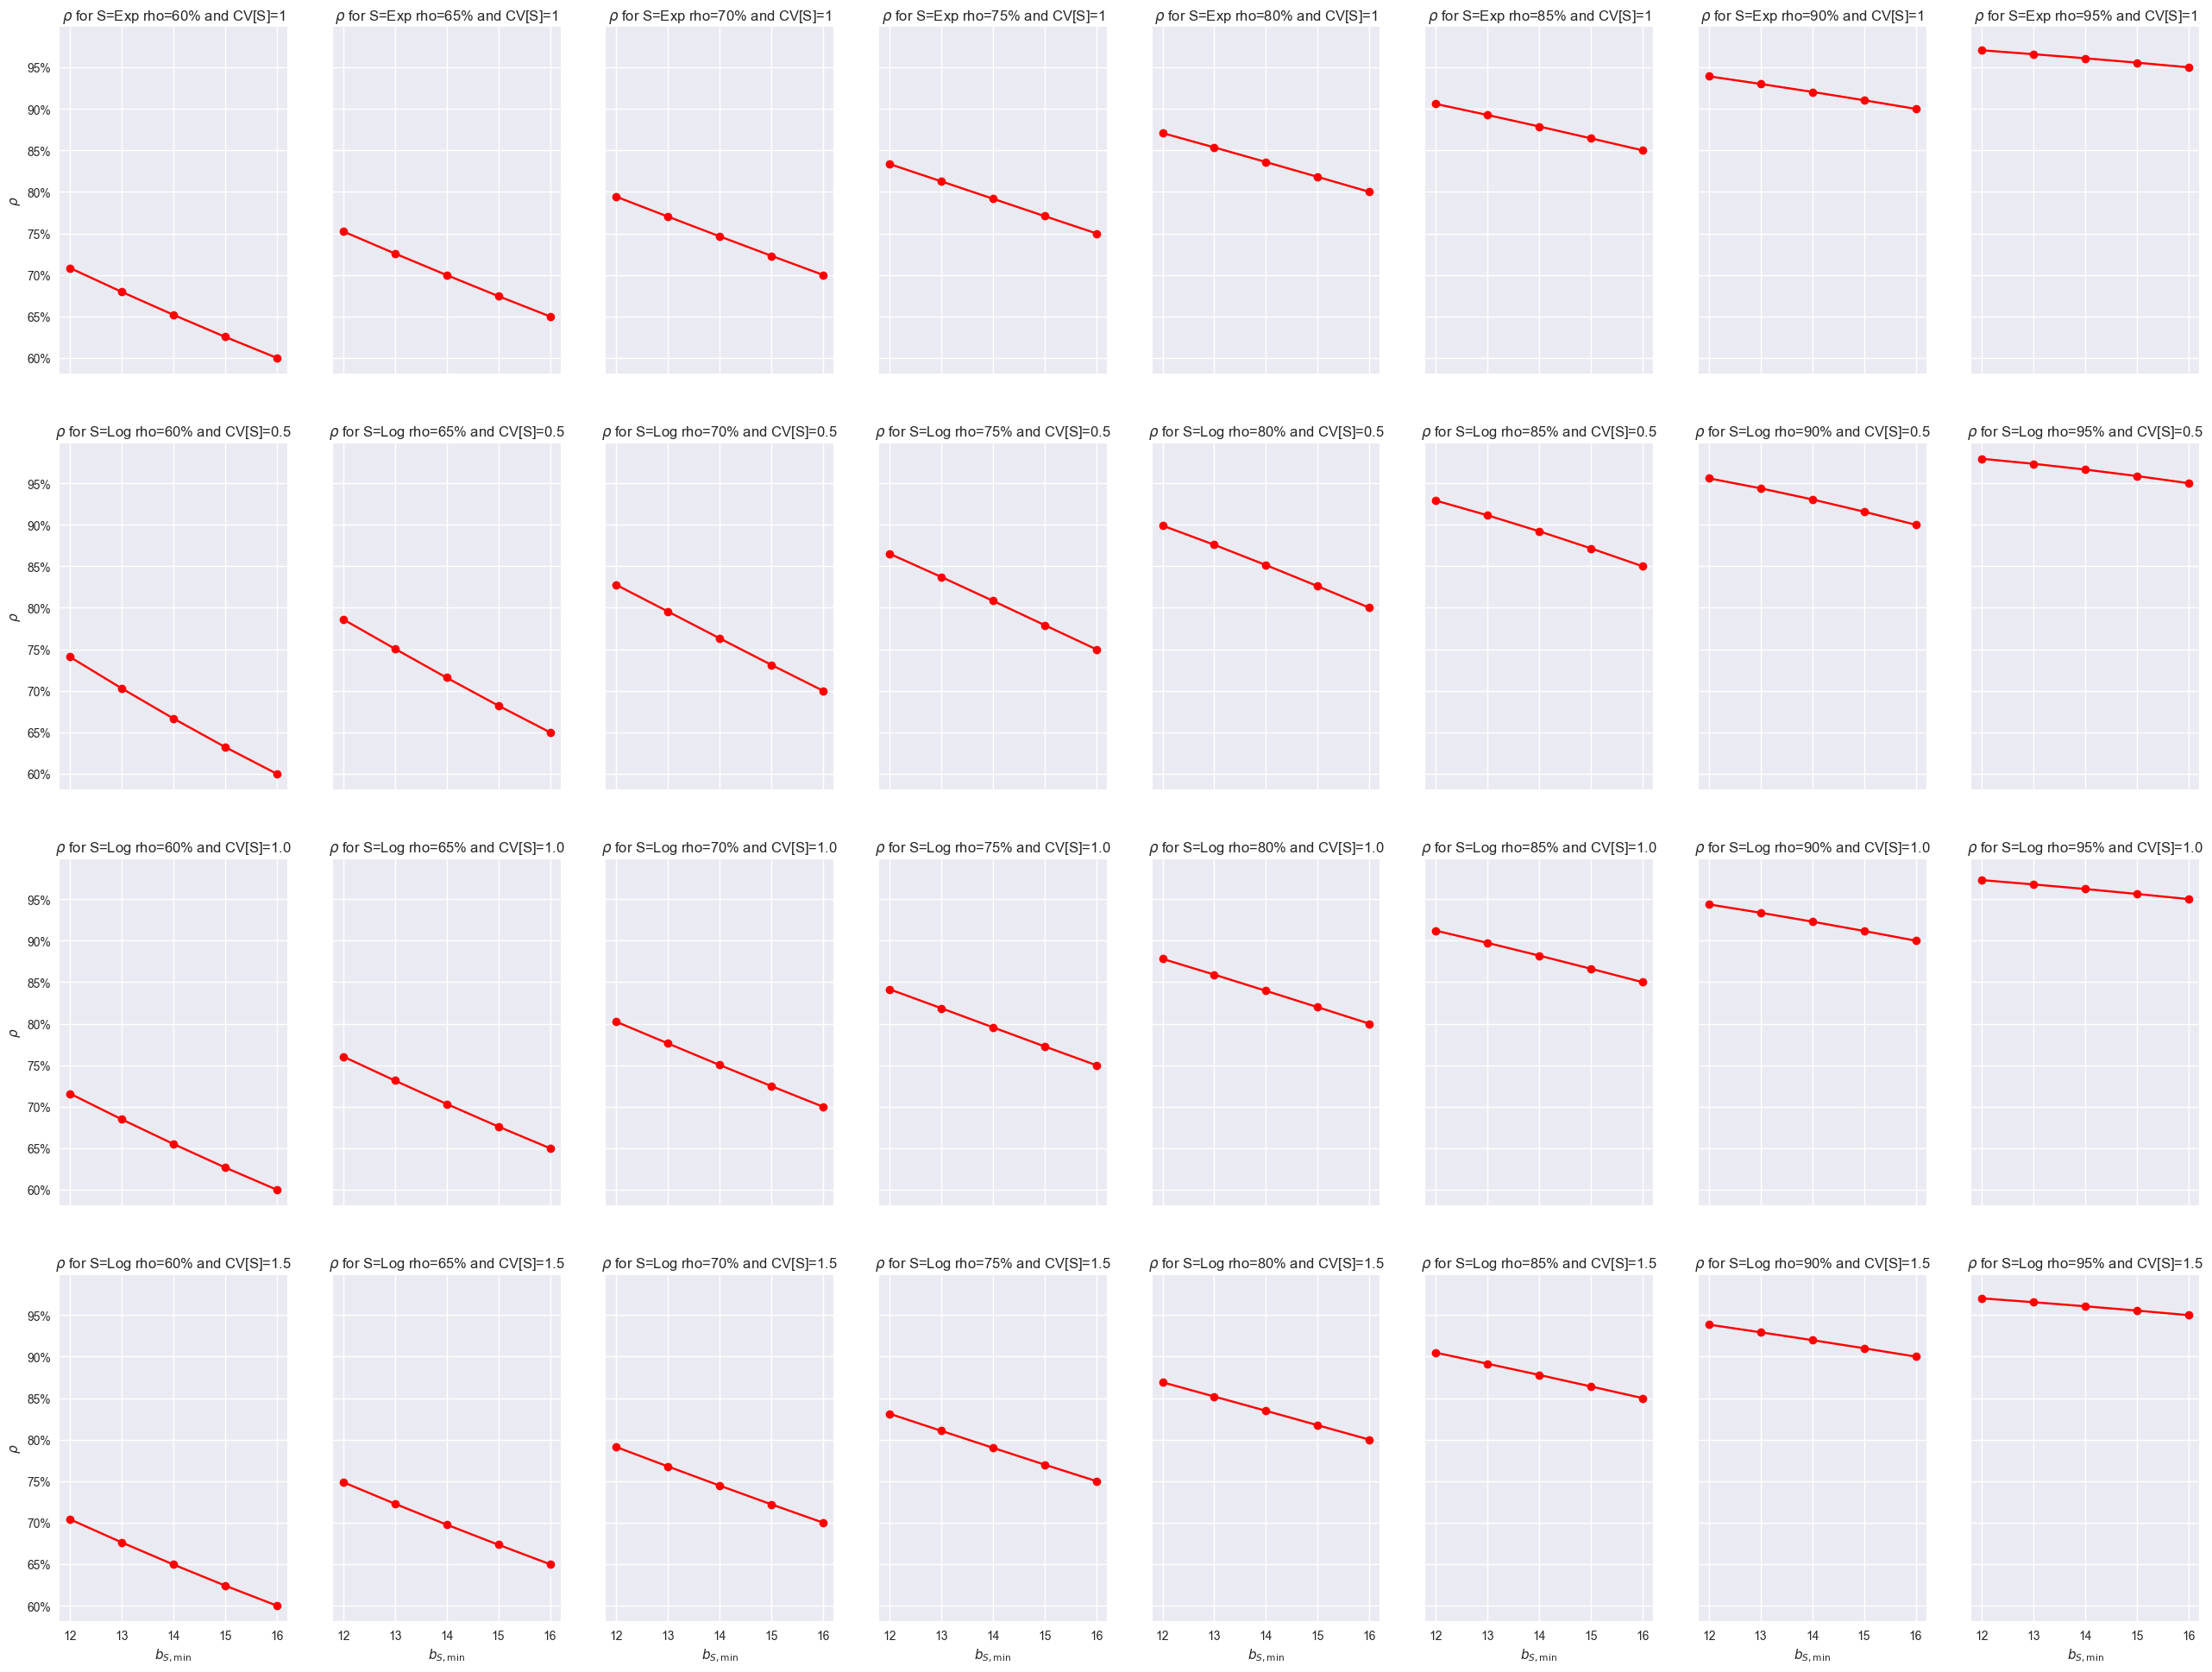

In [55]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i in range(4):
    if i == 0:
        S = "Exp"
        CVS = 1
    else:
        S = "Log"
        CVS = 0.5 * i
    for j in range(8):
        rho = 0.60 + j * 0.05
        plot_sim_data = []
        for rec in [r for r in data_bI1 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho]:
            b = rec["b_min"]
            name = rec["name_short"]
            plot_sim_data.append({"b": b, "name": name, "rho": rec["rho"]})

        plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

        x = [rec["b"] for rec in plot_sim_data]
        y_sim = [rec["rho"] for rec in plot_sim_data]

        ax1 = ax[i][j]

        ax1.plot(x, y_sim, 'red', marker='o')
        ax1.set_xticks(x)
        if j == 0:
            ax1.set_ylabel("$\\rho$")
        ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

        if i == 3:
            ax1.set_xlabel("$b_{S,\\min}$")

        ax1.set_title(f"$\\rho$ for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

# fig.savefig("images/Model04-rho-details.png", format="png", bbox_inches='tight', pad_inches=0)

### Results for $b_I=1,2,3,4$ (Model 4)

In [56]:
def plot_EWrel(ax, bI, color, label):
    for i in range(4):
        if i == 0:
            S = "Exp"
            CVS = 1
        else:
            S = "Log"
            CVS = 0.5 * i
        for j in range(8):
            rho = 0.60 + j * 0.05
            plot_sim_data = []
            for rec in [r for r in data_bI1234 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho and r["bI"] == bI]:
                b = rec["b_min"]
                name = rec["name_short"]
                plot_sim_data.append({"b": b, "name": name, "E[W]": rec["E[W]rel"]})

            plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

            x = [rec["b"] for rec in plot_sim_data]
            y_sim = [rec["E[W]"] for rec in plot_sim_data]

            ax1 = ax[i][j]

            ax1.plot(x, y_sim, marker='o', color=color, label=label)
            ax1.set_xticks(x)
            if j == 0:
                ax1.set_ylabel("E[W] relative to $b_S$=16")

            if i == 3:
                ax1.set_xlabel("$b_{S,\\min}$")

            ax1.set_title(f"E[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")


def plot_EWabs(ax, bI, color, label):
    for i in range(4):
        if i == 0:
            S = "Exp"
            CVS = 1
        else:
            S = "Log"
            CVS = 0.5 * i
        for j in range(8):
            rho = 0.60 + j * 0.05
            plot_sim_data = []
            for rec in [r for r in data_bI1234 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho and r["bI"] == bI]:
                b = rec["b_min"]
                name = rec["name_short"]
                plot_sim_data.append({"b": b, "name": name, "E[W]": rec["E[W]"] / 60})

            plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

            x = [rec["b"] for rec in plot_sim_data]
            y_sim = [rec["E[W]"] for rec in plot_sim_data]

            ax1 = ax[i][j]

            ax1.plot(x, y_sim, marker='o', color=color, label=label)
            ax1.set_xticks(x)
            if j == 0:
                ax1.set_ylabel("E[W] in min.")

            if i == 3:
                ax1.set_xlabel("$b_{S,\\min}$")

            ax1.set_title(f"E[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

def plot_CVW(ax, bI, color, label):
    max_rel_delta_W = 0
    max_rel_delta_V = 0
    for i in range(4):
        if i == 0:
            S = "Exp"
            CVS = 1
        else:
            S = "Log"
            CVS = 0.5 * i
        for j in range(8):
            rho = 0.60 + j * 0.05
            plot_sim_data = []
            for rec in [r for r in data_bI1234 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho and r["bI"] == bI]:
                b = rec["b_min"]
                name = rec["name_short"]
                plot_sim_data.append({"b": b, "name": name, "CV[W]": rec["CV[W]"], "CV[V]": rec["CV[V]"]})

            plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

            x = [rec["b"] for rec in plot_sim_data]
            y_sim = [rec["CV[W]"] for rec in plot_sim_data]
            y_sim_CVV = [rec["CV[V]"] for rec in plot_sim_data]
            rel_delta_W = abs((y_sim[4] - y_sim[0]) / y_sim[4])
            max_rel_delta_W = max(max_rel_delta_W, rel_delta_W)
            rel_delta_V = abs((y_sim_CVV[4] - y_sim_CVV[0]) / y_sim_CVV[4])
            max_rel_delta_V = max(max_rel_delta_V, rel_delta_V)

            ax1 = ax[i][j]

            ax1.plot(x, y_sim, marker='o', color=color, label=label)
            ax1.set_xticks(x)
            if j == 0:
                ax1.set_ylabel("CV[W]")

            if i == 3:
                ax1.set_xlabel("$b_{S,\\min}$")

            ax1.set_title(f"CV[W] for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

    return max_rel_delta_W, max_rel_delta_V

def plot_rho(ax, bI, color, label):
    for i in range(4):
        if i == 0:
            S = "Exp"
            CVS = 1
        else:
            S = "Log"
            CVS = 0.5 * i
        for j in range(8):
            rho = 0.60 + j * 0.05
            plot_sim_data = []
            for rec in [r for r in data_bI1234 if r["S"] == S and r["model_CV[S]"] == CVS and r["model_rho"] == rho and r["bI"] == bI]:
                b = rec["b_min"]
                name = rec["name_short"]
                plot_sim_data.append({"b": b, "name": name, "rho": rec["rho"]})

            plot_sim_data = sorted(plot_sim_data, key=lambda rec: rec["b"])

            x = [rec["b"] for rec in plot_sim_data]
            y_sim = [rec["rho"] for rec in plot_sim_data]

            ax1 = ax[i][j]

            ax1.plot(x, y_sim, marker='o', color=color, label=label)
            ax1.set_xticks(x)
            ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
            if j == 0:
                ax1.set_ylabel("$\\rho$")

            if i == 3:
                ax1.set_xlabel("$b_{S,\\min}$")

            ax1.set_title(f"$\\rho$ for S={S} rho={rho * 100:0.0f}% and CV[S]={CVS}")

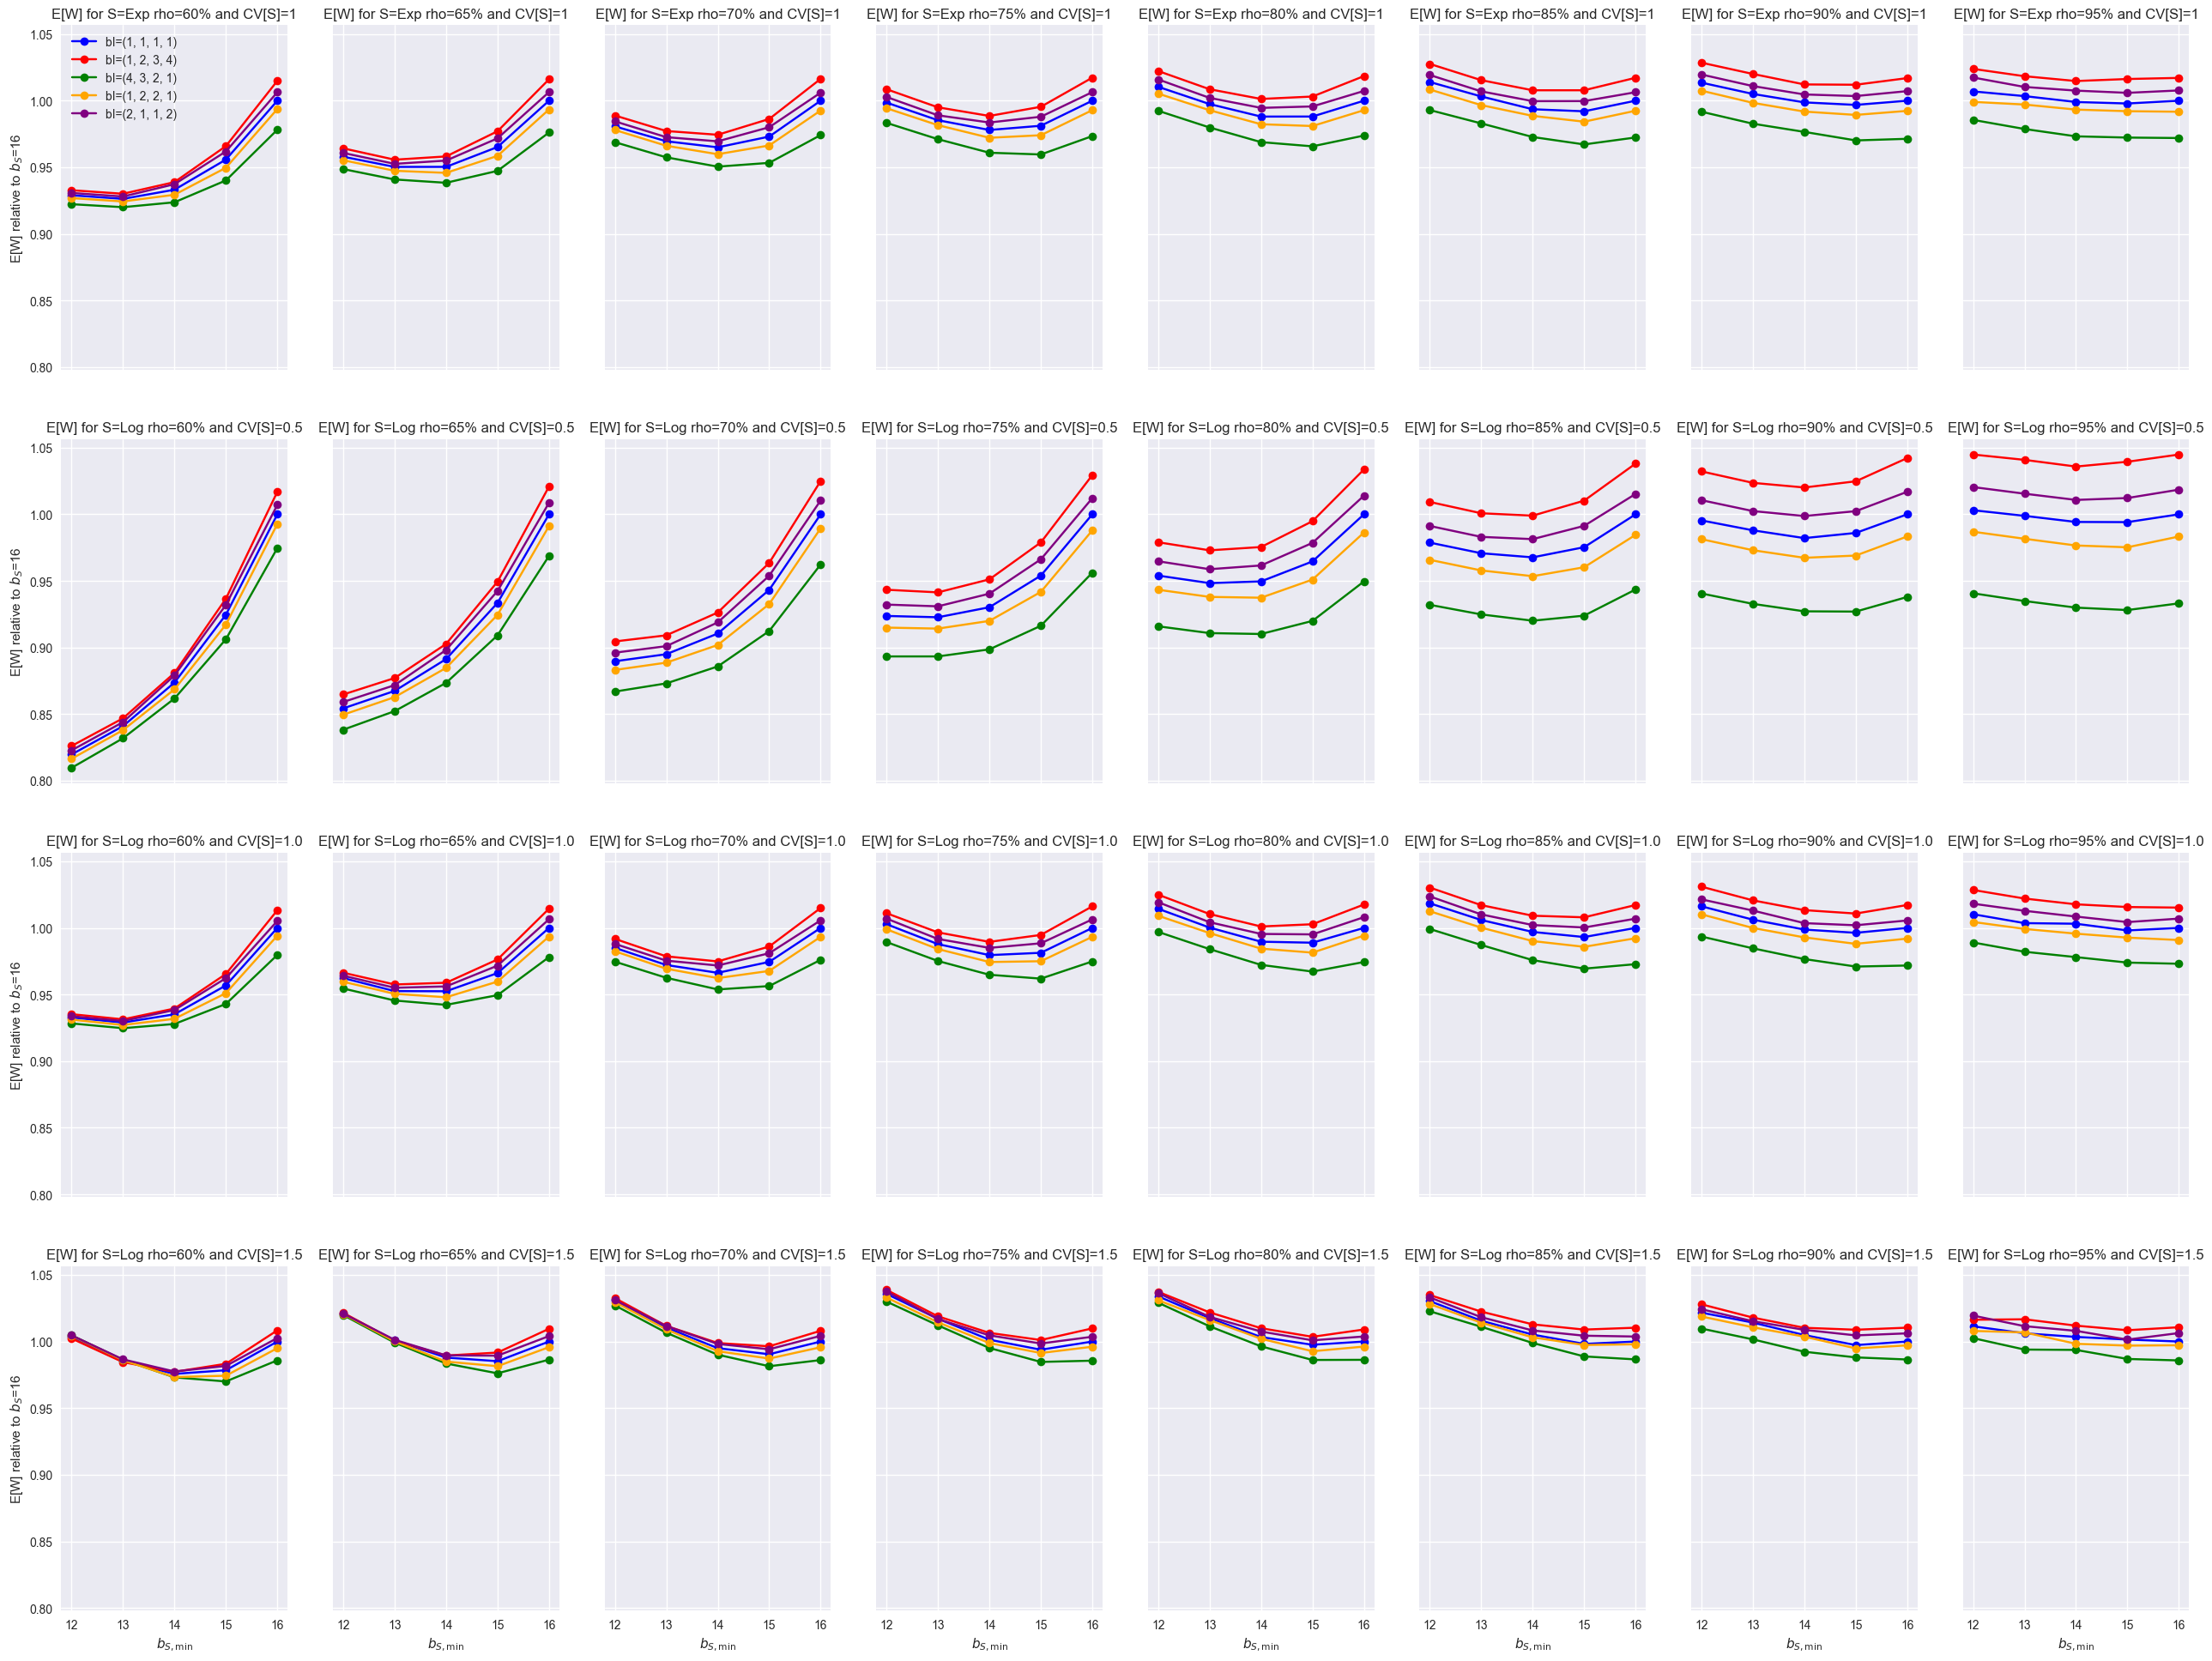

In [57]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i, (bI_rate, color) in enumerate(zip(bI_rates_levels, colors)):
    bI_str = "".join(map(str, bI_rate))
    plot_EWrel(ax, bI_str, color, f"bI={tuple(bI_rate)}")
ax[0][0].legend()

# fig.savefig("images/Model05-EWrel-details.png", format="png", bbox_inches='tight', pad_inches=0)

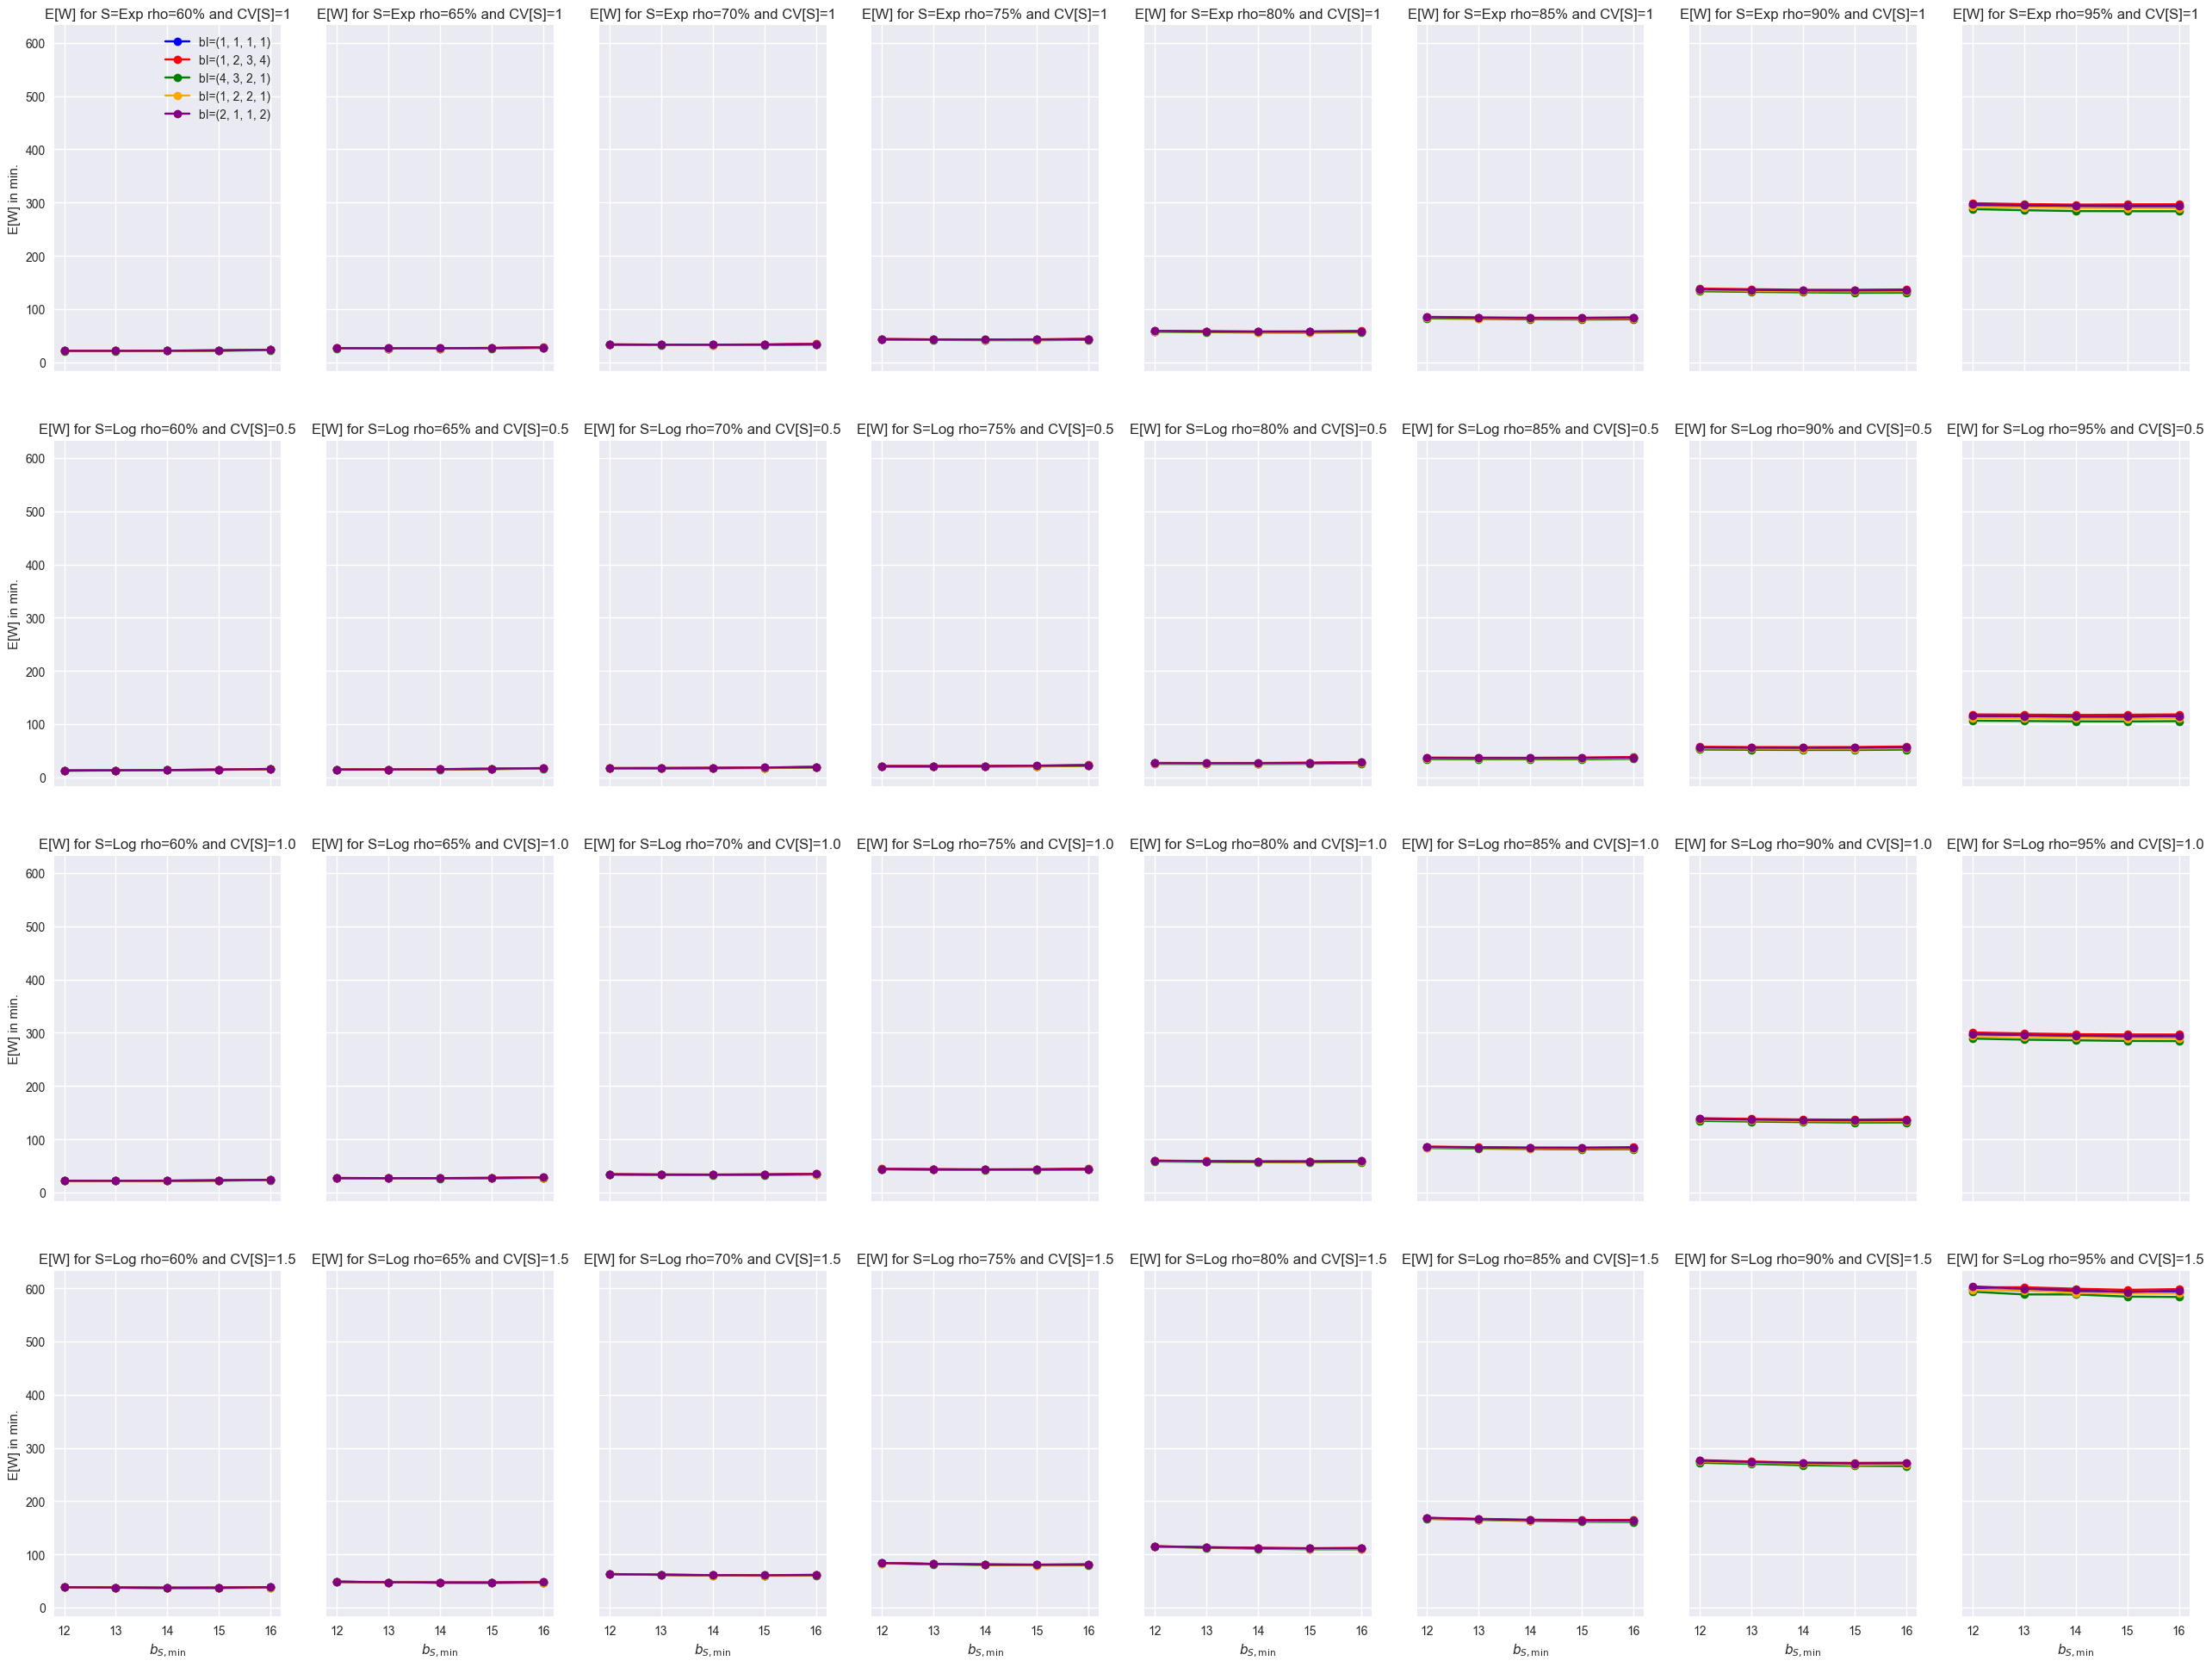

In [58]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i, (bI_rate, color) in enumerate(zip(bI_rates_levels, colors)):
    bI_str = "".join(map(str, bI_rate))
    plot_EWabs(ax, bI_str, color, f"bI={tuple(bI_rate)}")
ax[0][0].legend()

# fig.savefig("images/Model05-EW-details.png", format="png", bbox_inches='tight', pad_inches=0)

Maximum relative delta (W): 12.82%
Maximum relative delta (V): 8.11%


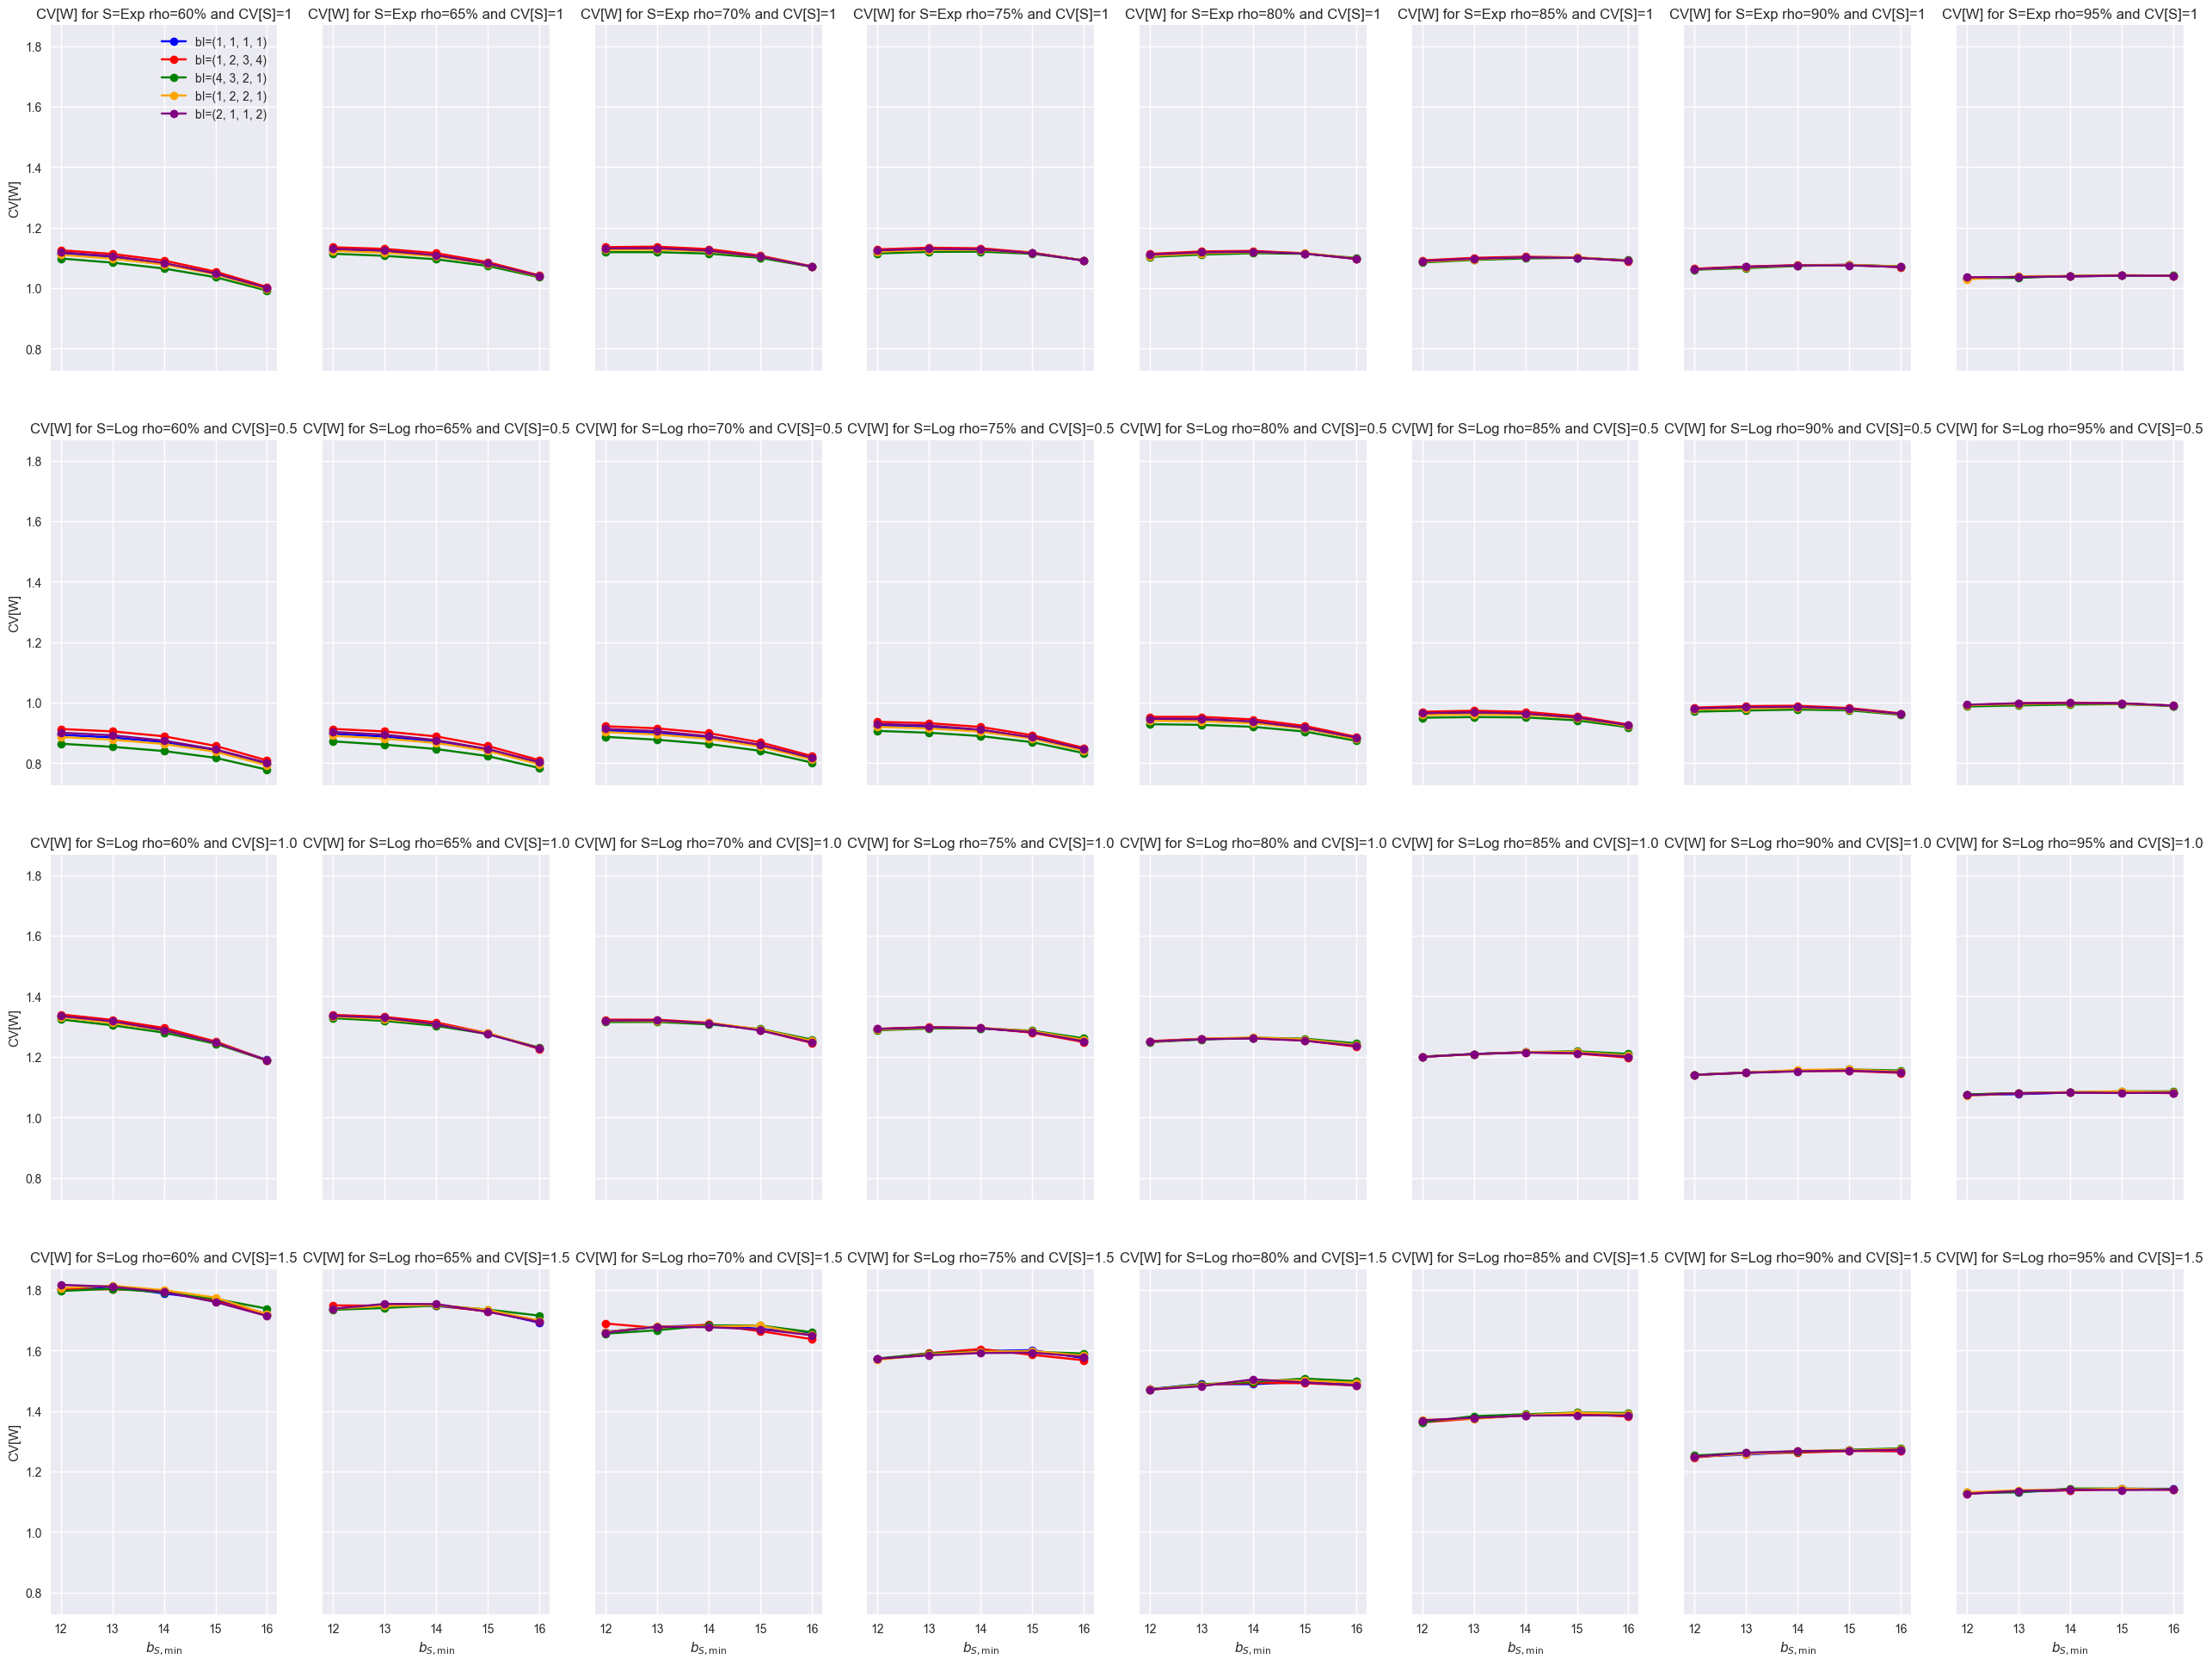

In [ ]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

max_rel_delta_W = 0
max_rel_delta_V = 0

for i, (bI_rate, color) in enumerate(zip(bI_rates_levels, colors)):
    bI_str = "".join(map(str, bI_rate))
    rel_delta_W, rel_delta_V = plot_CVW(ax, bI_str, color, f"bI={tuple(bI_rate)}")
    max_rel_delta_W = max(max_rel_delta_W, rel_delta_W)
    max_rel_delta_V = max(max_rel_delta_V, rel_delta_V)
ax[0][0].legend()

print(f"Maximum relative delta (W): {max_rel_delta_W * 100:.2f}%")
print(f"Maximum relative delta (V): {max_rel_delta_V * 100:.2f}%")

# fig.savefig("images/Model05-CVW-details.png", format="png", bbox_inches='tight', pad_inches=0)

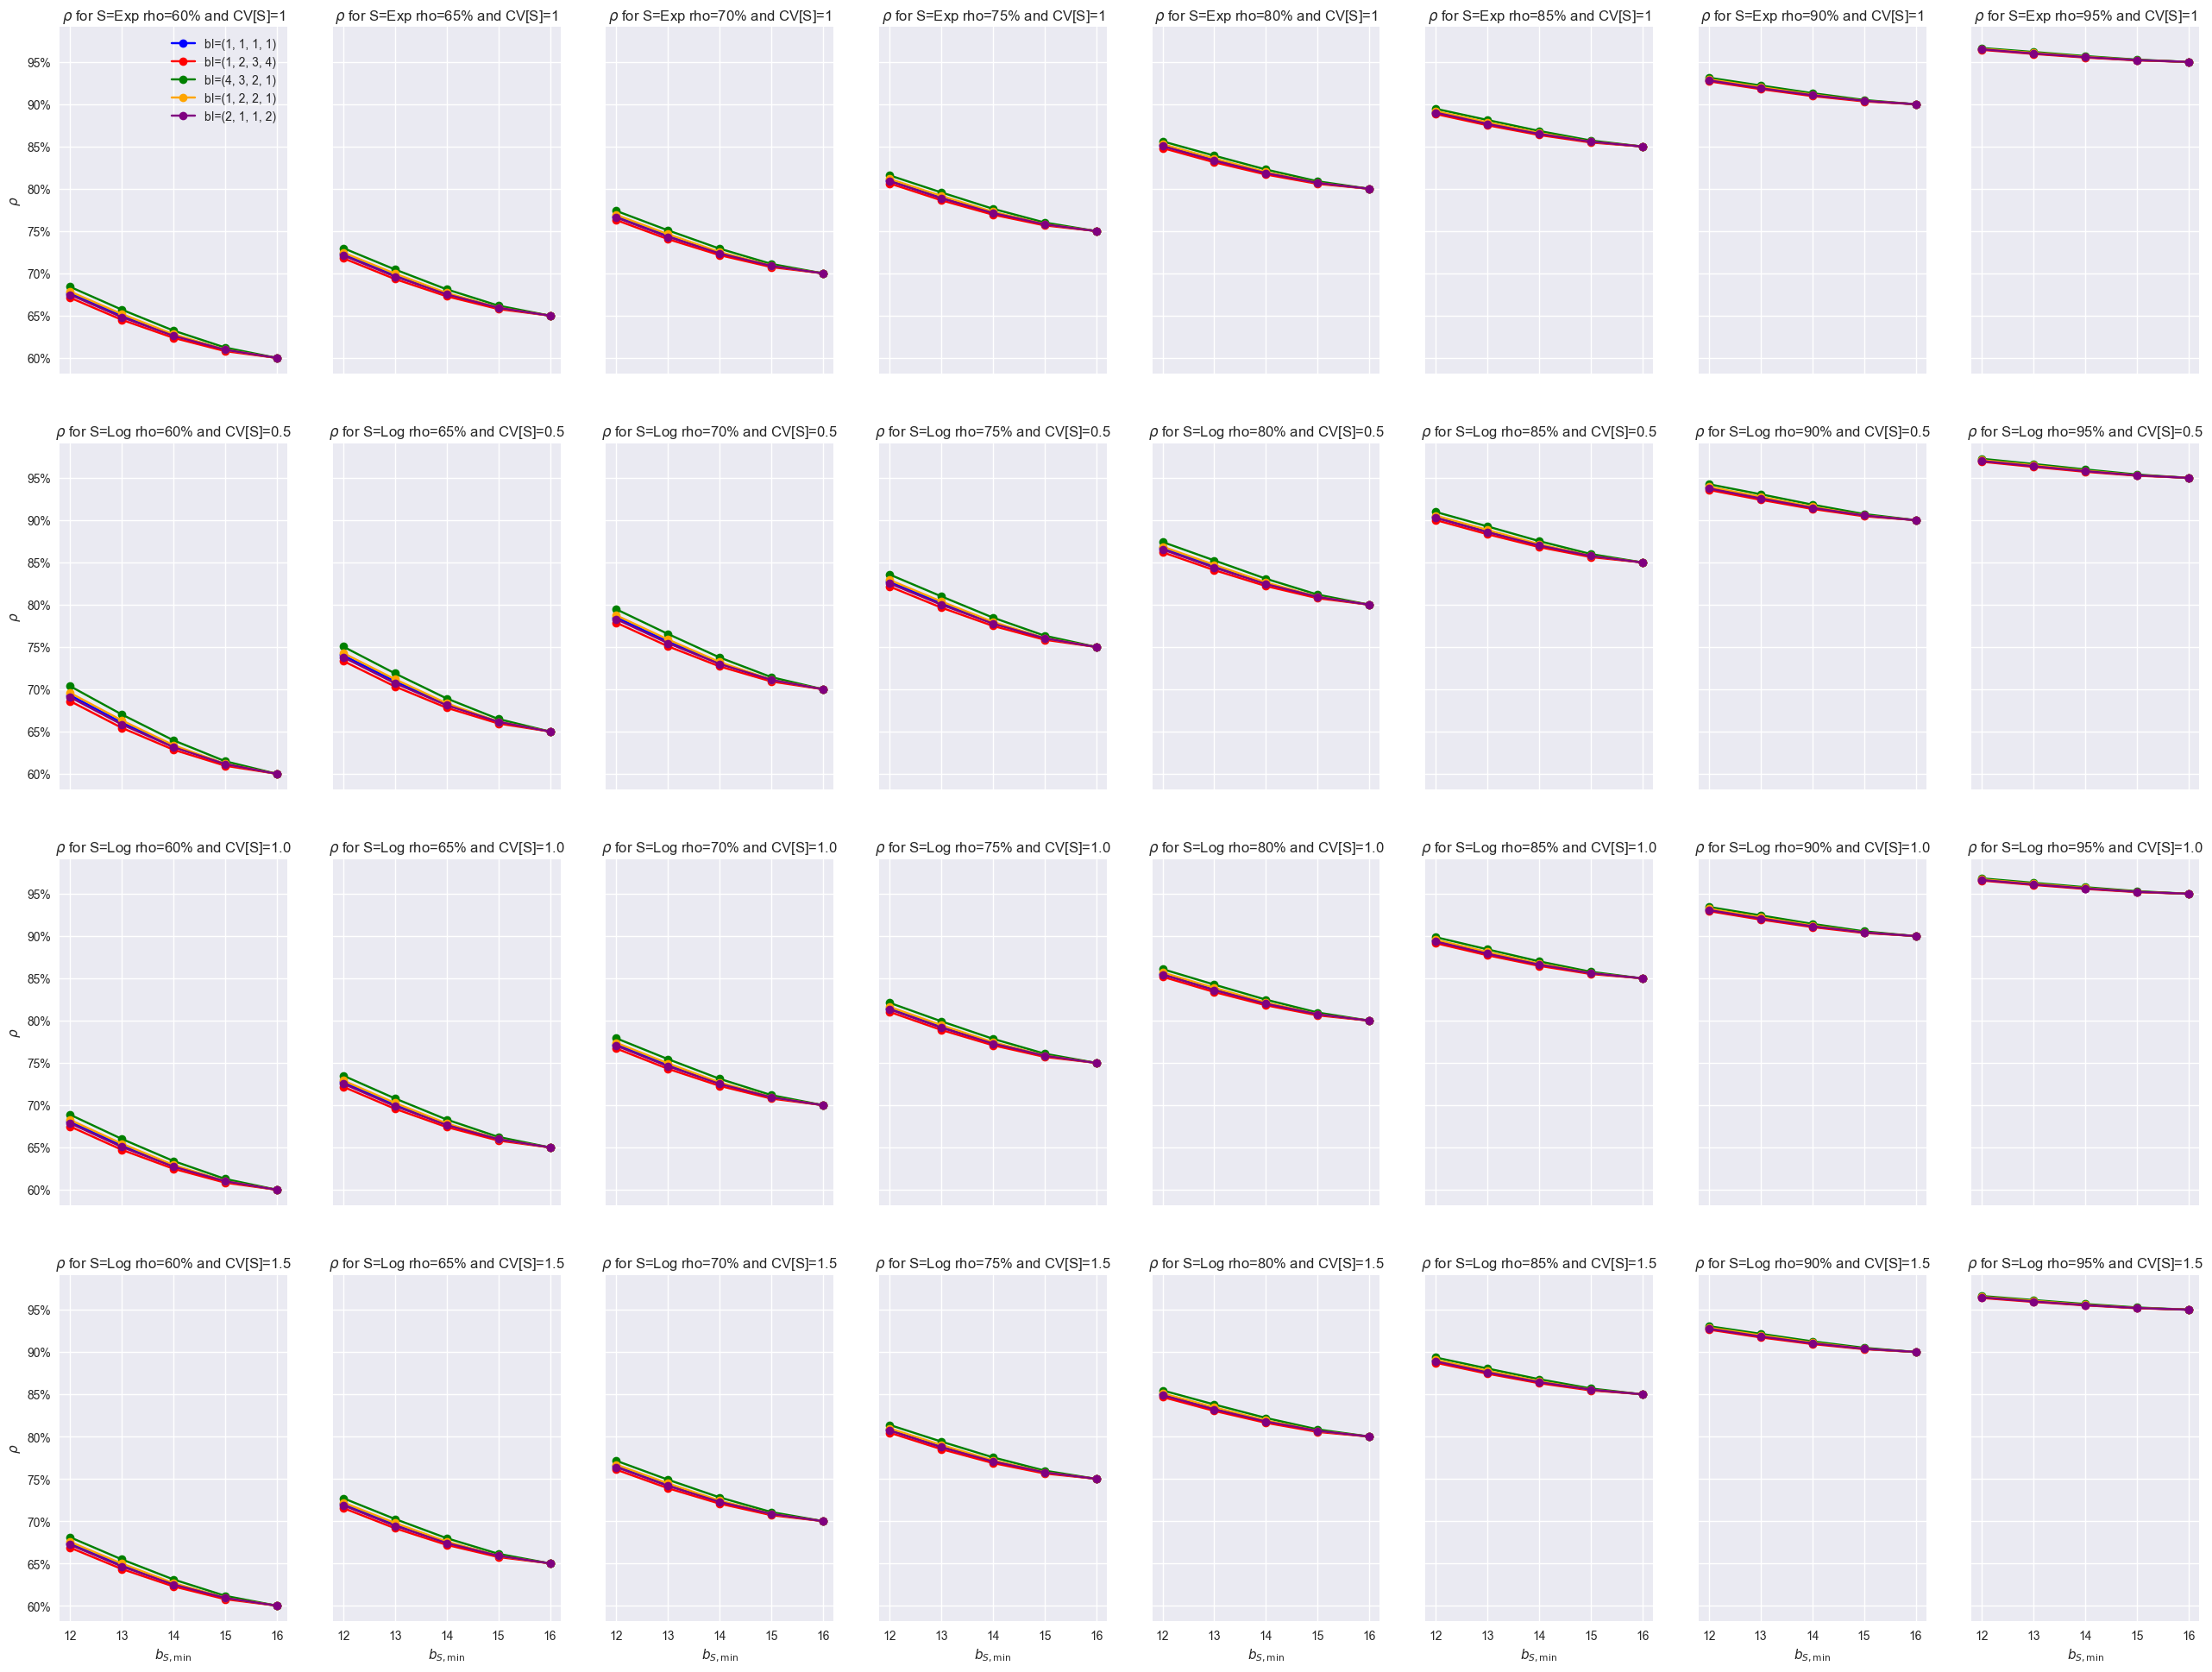

In [60]:
fig, ax = plt.subplots(4, 8, figsize=(32, 24), sharex=True, sharey=True)

for i, (bI_rate, color) in enumerate(zip(bI_rates_levels, colors)):
    bI_str = "".join(map(str, bI_rate))
    plot_rho(ax, bI_str, color, f"bI={tuple(bI_rate)}")
ax[0][0].legend()

# fig.savefig("images/Model05-rho-details.png", format="png", bbox_inches='tight', pad_inches=0)